# Wavefield · VTI · multi-method + shear suppression

SWEEP exposes several VTI (vertical transverse isotropy) acoustic
equations through a single unified entry point
[`AcousticAniso(method=..., symmetry='vti', ndim=2)`](https://github.com/DeepWave-KAUST/sweep/blob/dev/src/sweep/equations/acoustic_aniso.py).
All approximate qP-wave kinematics in a transversely isotropic medium
but differ in field structure and what "models" they consume:

| Method | Models |
|---|---|
| `method='duveneck'` | `vp, ε, δ, ρ` |
| `method='liang'` | `vp, ε, δ` |
| `method='alkhalifah'` | `vv, v_nmo, η` |

Geometry and parameters use the canonical Duveneck Fig 2 setup
— ``vp=1500 m/s``, ``ε=0.25``, ``δ=0`` — where ε > δ produces a
**diamond-shaped qP wavefront**. The Duveneck 1st-order formulation
additionally exhibits the well-known slow inner diamond-shaped *S*
artefact — section 6 shows how to suppress it.


## 1. Parameters

We define one set of Thomsen parameters (`vp`, `ε`, `δ`) and convert
to the Alkhalifah parameterization for ``AcousticTariq``. **The
middle Tariq model ``v`` is the NMO velocity, not the horizontal
velocity**:

$$
v_\text{NMO} = v_p \sqrt{1 + 2\delta}, \qquad
\eta = \frac{\varepsilon - \delta}{1 + 2\delta}
$$

The horizontal phase velocity then **emerges from the equation** as
$v_h = v_\text{NMO} \sqrt{1 + 2\eta} = v_p \sqrt{1 + 2\varepsilon}$.
If you mistakenly pass $v_h$ into the ``v`` slot, the inner
$(1 + 2\eta)\, v^2$ term in the qP equation overstates the
horizontal velocity squared by a factor $(1+2\eta)$ and the
Alkhalifah wavefront races ahead in x relative to Duveneck/Liang.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import AcousticAniso
from sweep.equations._anisotropy_utils import smooth_delta_to_epsilon_disk
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

shape = (193, 193)            # 960 m × 960 m at 5 m spacing (after PML strip)
dh    = (5.0, 5.0)
dt    = 1e-3
nt    = 700                   # 0.7 s record
abcn  = 50
spatial_order = 4
freq, delay = 15.0, 0.15
snapshot_times = [200, 350, 500]

vp_val   = 1500.0
eps_val  = 0.25
delta_val = 0.0
rho_val  = 1000.0

# Alkhalifah parameterization (Tariq qP): the 'v' model is the NMO
# velocity v_nmo = vp √(1+2δ); the horizontal phase velocity emerges
# as v_nmo √(1+2η) inside the equation. η = (ε-δ)/(1+2δ).
vv_val  = vp_val
v_val   = vp_val * np.sqrt(1.0 + 2.0 * delta_val)
eta_val = (eps_val - delta_val) / (1.0 + 2.0 * delta_val)
print(f'Thomsen   : vp={vp_val}, eps={eps_val}, delta={delta_val}')
print(f'Alkhalifah: vv={vv_val:.1f}, v_nmo={v_val:.1f}, eta={eta_val:.3f}  '
      f'(horizontal vp = v_nmo √(1+2η) = {v_val*np.sqrt(1+2*eta_val):.1f})')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


Thomsen   : vp=1500.0, eps=0.25, delta=0.0
Alkhalifah: vv=1500.0, v_nmo=1500.0, eta=0.250  (horizontal vp = v_nmo √(1+2η) = 1837.1)
device: cuda


## 2. Uniform anisotropic model, centred source

Source at grid centre. The 2nd-order pseudo-acoustic methods (Liang /
Alkhalifah) inject into the auxiliary pressure-like field ``h1``; the
1st-order Duveneck method injects into the stress fields ``sH``+``sV``
(its defaults). One dummy receiver — the API requires it but this demo
is wavefield-only.


In [2]:
nz, nx = shape
vp_np    = np.full(shape, vp_val,    dtype=np.float32)
eps_np   = np.full(shape, eps_val,   dtype=np.float32)
delta_np = np.full(shape, delta_val, dtype=np.float32)
rho_np   = np.full(shape, rho_val,   dtype=np.float32)
vv_np    = np.full(shape, vv_val,    dtype=np.float32)
v_np     = np.full(shape, v_val,     dtype=np.float32)
eta_np   = np.full(shape, eta_val,   dtype=np.float32)

src_iz, src_ix = nz // 2, nx // 2
sources   = np.array([[src_ix, src_iz]], dtype=np.int64)
receivers = np.array([[[src_ix, src_iz + 8]]], dtype=np.int64)

t = np.arange(nt, dtype=np.float32) * dt
wavelet = (1e6 * ricker(t - delay, f=freq)).astype(np.float32)


## 3. Build the three solvers via `AcousticAniso`

``AcousticAniso(method=...)`` is a factory: instantiating it returns the
underlying equation class, ready to feed into ``PropTorch``. Same
geometry + same wavelet across all three — only ``method`` changes.
Snapshot recording (``return_wavefield=True``) needs ``impl='eager',
use_ckpt=False``; the equation-level fallback in ``PropTorch`` would
downgrade Liang/Alkhalifah to eager anyway because they have no
compiled CUDA hook.


In [3]:
# spatial_order is owned by the equation (passed to AcousticAniso
# above); PropTorch reads the FD halo off the equation, so it is
# not repeated here.
common_solver_kw = dict(shape=shape, dh=dh, dt=dt, nt=nt,
                        abcn=abcn, impl='eager', use_ckpt=False)

eq_duveneck   = AcousticAniso(method='duveneck',   symmetry='vti',
                              spatial_order=spatial_order, device=device)
eq_liang      = AcousticAniso(method='liang',      symmetry='vti',
                              spatial_order=spatial_order, device=device)
eq_alkhalifah = AcousticAniso(method='alkhalifah', symmetry='vti',
                              spatial_order=spatial_order, device=device)

# Each equation already declares its own default_source_fields /
# default_receiver_fields, so the source_type / receiver_type kwargs
# can be omitted entirely — PropTorch will read them off the equation:
#   Duveneck   → src=['sH','sV'], rec=['vz']
#   Liang      → src=['h1'],      rec=['h1']
#   Alkhalifah → src=['h1'],      rec=['h1']
solver_duveneck   = PropTorch(eq_duveneck,   **common_solver_kw)
solver_liang      = PropTorch(eq_liang,      **common_solver_kw)
solver_alkhalifah = PropTorch(eq_alkhalifah, **common_solver_kw)

for name, s, eq in [('Duveneck',   solver_duveneck,   eq_duveneck),
                    ('Liang',      solver_liang,      eq_liang),
                    ('Alkhalifah', solver_alkhalifah, eq_alkhalifah)]:
    print(f'{name:10s}  class={type(eq).__name__:18s}  impl={s.impl:6s}  src={list(s.source_type)}')


Duveneck    class=AcousticVTI1st      impl=eager   src=['sH', 'sV']
Liang       class=AcousticVTI         impl=eager   src=['h1']
Alkhalifah  class=AcousticTariq       impl=eager   src=['h1']


### Aside · which sources and receivers does this equation accept?

`AcousticVTI` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [4]:
print('models (input order matters!):')
for spec in eq_duveneck.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', eq_duveneck.default_source_fields, '/', eq_duveneck.default_receiver_fields)
print('receivers :')
for spec in eq_duveneck.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — Vertical P-wave velocity.
  - epsilon   — Thomsen epsilon anisotropy parameter (ε ≥ δ required).
  - delta     — Thomsen delta anisotropy parameter.
  - rho      [kg/m^3]  — Density.
defaults  : ['sH', 'sV'] / ['vz']
receivers :
  - vx       aliases=('velocity_x',)  — Particle velocity in x.
  - vz       aliases=('velocity_z',)  — Particle velocity in z.
  - sH       aliases=('stress_h', 'sigma_H')  — Horizontal normal stress σ_11 = σ_22.
  - sV       aliases=('stress_v', 'sigma_V')  — Vertical normal stress σ_33.


## 4. Forward modeling with wavefield snapshots

In [5]:
def t_(arr): return torch.tensor(arr, device=device)

with torch.no_grad():
    _, snaps_duv = solver_duveneck(
        wavelet, sources, receivers,
        models=[t_(vp_np), t_(eps_np), t_(delta_np), t_(rho_np)],
        return_wavefield=True, snapshot_times=snapshot_times)
    _, snaps_lia = solver_liang(
        wavelet, sources, receivers,
        models=[t_(vp_np), t_(eps_np), t_(delta_np)],
        return_wavefield=True, snapshot_times=snapshot_times)
    _, snaps_alk = solver_alkhalifah(
        wavelet, sources, receivers,
        models=[t_(vv_np), t_(v_np), t_(eta_np)],
        return_wavefield=True, snapshot_times=snapshot_times)

for name, snaps in [('Duveneck', snaps_duv), ('Liang', snaps_lia), ('Alkhalifah', snaps_alk)]:
    print(f'{name:10s} snaps {tuple(snaps.shape)}')


Duveneck   snaps (3, 8, 1, 1, 293, 293)
Liang      snaps (3, 6, 1, 1, 293, 293)
Alkhalifah snaps (3, 8, 1, 1, 293, 293)


## 5. Wavefield snapshots — qP diamond

Each row is one method; columns are the three snapshot times. The
first physical field is plotted:

- Duveneck → ``sH + sV`` (trace of the 2-D stress tensor — a
  pressure-like proxy that matches ``h1``'s units of meaning)
- Liang / Alkhalifah → ``h1`` (auxiliary pseudo-pressure field)

All three develop the same diamond-stretched qP front. The Duveneck
1st-order formulation additionally exposes a slower inner
diamond-shaped wavefront — the classic VTI shear artefact, visible in
the ``sH + sV`` channel. Liang's 2nd-order pseudo-acoustic and
Alkhalifah's η-acoustic suppress this branch by construction, so
their ``h1`` panels show only the outer qP front.


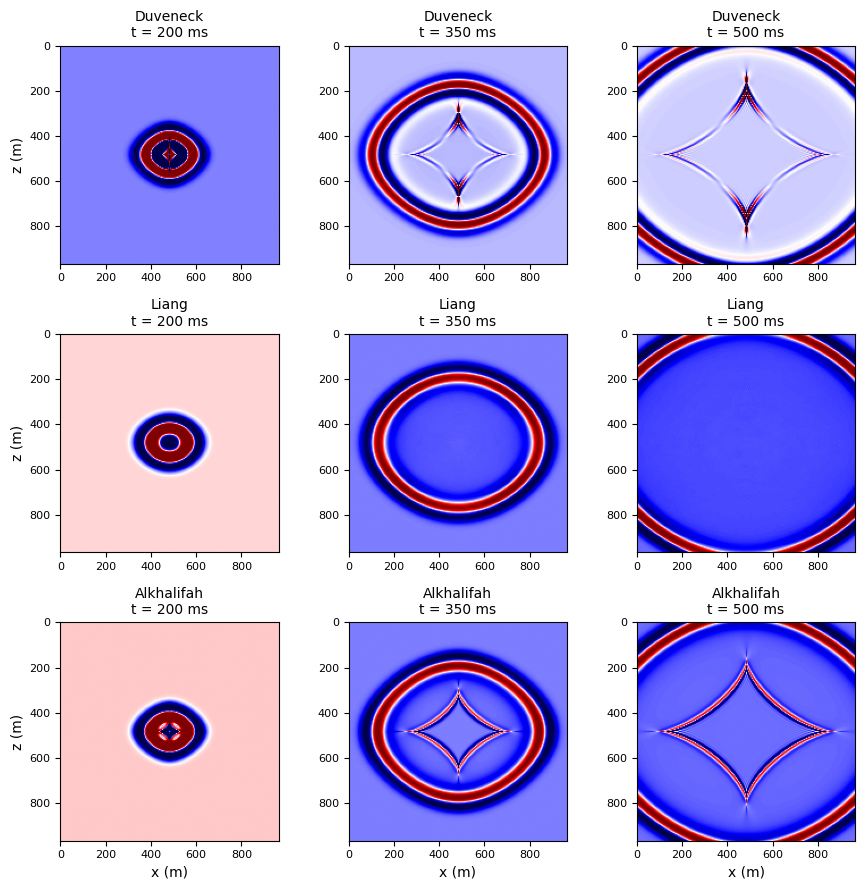

In [6]:
def crop_panel(snap_5d, t_idx, field_idx=0):
    # snap shape: (n_snaps, n_fields, batch, channel, nz_pad, nx_pad)
    full = snap_5d[t_idx, field_idx, 0, 0].cpu().numpy()
    return full[abcn:abcn + nz, abcn:abcn + nx]

# Duveneck has no 'pressure' field; reconstruct it as sH + sV (trace of
# the 2-D stress tensor) so the comparison with h1 is apples-to-apples.
sH_idx = eq_duveneck.wavefields.index('sH')
sV_idx = eq_duveneck.wavefields.index('sV')
def duveneck_p(t_idx):
    return crop_panel(snaps_duv, t_idx, sH_idx) + crop_panel(snaps_duv, t_idx, sV_idx)

rows = [
    ('Duveneck', [duveneck_p(i)            for i in range(len(snapshot_times))]),
    ('Liang',            [crop_panel(snaps_lia, i) for i in range(len(snapshot_times))]),
    ('Alkhalifah',       [crop_panel(snaps_alk, i) for i in range(len(snapshot_times))]),
]

fig, axes = plt.subplots(len(rows), len(snapshot_times), figsize=(9, 9))
extent = [0, nx * dh[1], nz * dh[0], 0]
for r, (label, panels) in enumerate(rows):
    for c, t_idx in enumerate(snapshot_times):
        panel = panels[c]
        vmin, vmax = np.percentile(panel, [2, 98])
        ax = axes[r, c]
        ax.imshow(panel, cmap='seismic', vmin=vmin, vmax=vmax,
                  aspect='equal', extent=extent)
        ax.set_title(f'{label}\nt = {t_idx * dt * 1000:.0f} ms', fontsize=10)
        if c == 0: ax.set_ylabel('z (m)')
        if r == len(rows) - 1: ax.set_xlabel('x (m)')
        ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()


## 6. Suppressing the Duveneck shear artefact (δ → ε disk taper)

Reproduces Duveneck (2008) Figure 2: a raised-cosine disk around the
source that tapers ``δ → ε`` inside its radius lets the pseudo-shear
branch couple to the P-wavefront cleanly, killing the slow inner
diamond. ``sweep.equations._anisotropy_utils.smooth_delta_to_epsilon_disk``
is the canonical helper.


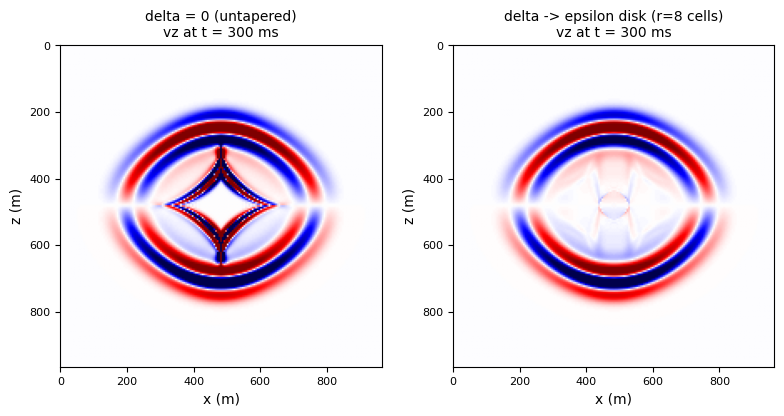

In [7]:
# Re-use the Duveneck solver but reinitialise to grab the suppressed run
delta_tapered_np = smooth_delta_to_epsilon_disk(
    eps_np, delta_np.copy(),
    source_grid_pos=(src_ix, src_iz),
    r_taper_grid=8,
)
suppression_snap = [300]

with torch.no_grad():
    _, snaps_unsup = solver_duveneck(
        wavelet, sources, receivers,
        models=[t_(vp_np), t_(eps_np), t_(delta_np),         t_(rho_np)],
        return_wavefield=True, snapshot_times=suppression_snap)
    _, snaps_sup = solver_duveneck(
        wavelet, sources, receivers,
        models=[t_(vp_np), t_(eps_np), t_(delta_tapered_np), t_(rho_np)],
        return_wavefield=True, snapshot_times=suppression_snap)

vz_idx = eq_duveneck.wavefields.index('vz')
def crop_field(snap, field_idx):
    return snap[0, field_idx, 0, 0, abcn:abcn + nz, abcn:abcn + nx].cpu().numpy()

field_unsup = crop_field(snaps_unsup, vz_idx)
field_sup   = crop_field(snaps_sup,   vz_idx)

# Shared colormap range — fixed by the unsuppressed run — so the right
# panel visibly fades out the inner diamond rather than auto-rescaling
# it back to full contrast.
vmin, vmax = np.percentile(field_unsup, [2, 98])

panels = [
    ('delta = 0 (untapered)',                   field_unsup),
    ('delta -> epsilon disk (r=8 cells)',       field_sup),
]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (label, field) in zip(axes, panels):
    ax.imshow(field, cmap='seismic', vmin=vmin, vmax=vmax,
              aspect='equal', extent=extent)
    ax.set_title(f'{label}\nvz at t = {suppression_snap[0] * dt * 1000:.0f} ms', fontsize=10)
    ax.set_xlabel('x (m)'); ax.set_ylabel('z (m)')
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()


## 7. 3-D extension — `AcousticVTI1st3D`

The Duveneck velocity-stress formulation lifts straight to 3-D as
`AcousticVTI1st3D` (`vp, ε, δ, ρ`; wavefields `vx, vy, vz, sH, sV`).
Here we fire one explosion at the centre of a small 3-D cube and look
at three orthogonal slices of `vz` — the qP wavefront takes the same
diamond shape, just sliced in three planes. The grid is intentionally
modest (101³) so the snapshot runs in a few seconds; the full
401³ Duveneck Fig 1 reproduction lives in git history.

vz cube shape: (101, 101, 101)


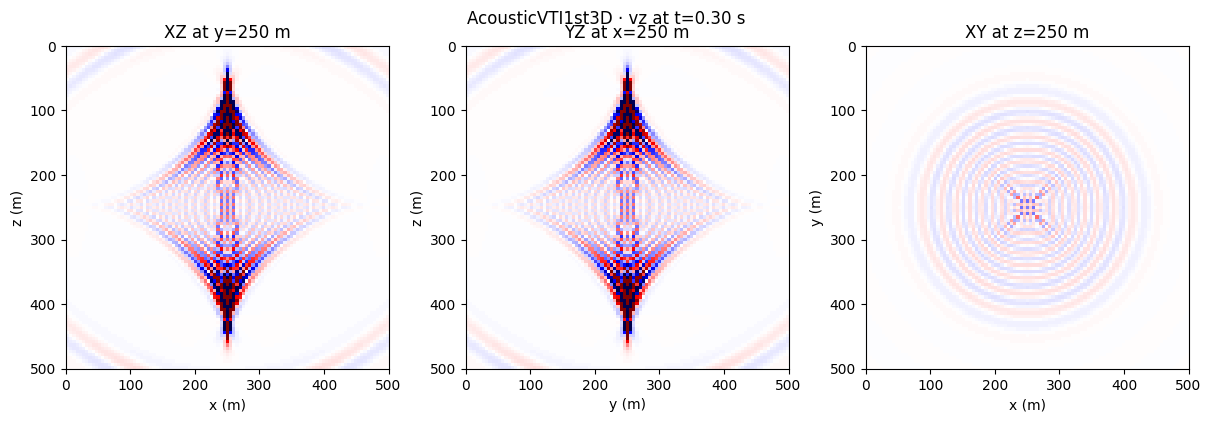

In [8]:
from sweep.equations import AcousticVTI1st3D

nz3 = ny3 = nx3 = 101
dh3 = 5.0
dt3 = 1e-3
nt3 = 300                  # 0.3 s record
abcn3 = 30
freq3, delay3 = 25.0, 0.10

shape3 = (nz3, ny3, nx3)
vp3   = torch.full(shape3, 1500.0, device=device)
eps3  = torch.full(shape3, 0.25,   device=device)
del3  = torch.full(shape3, 0.0,    device=device)
rho3  = torch.full(shape3, 1000.0, device=device)

# 3-D source / receiver coords are (ix, iy, iz)
src_ix3, src_iy3, src_iz3 = nx3 // 2, ny3 // 2, nz3 // 2
sources3   = np.array([[src_ix3, src_iy3, src_iz3]], dtype=np.int64)
receivers3 = np.array([[[src_ix3, src_iy3, src_iz3]]], dtype=np.int64)

t3 = np.arange(nt3, dtype=np.float32) * dt3
wavelet3 = (1e6 * ricker(t3 - delay3, f=freq3)).astype(np.float32)

eq3 = AcousticVTI1st3D(spatial_order=4, device=device)
solver3 = PropTorch(eq3, shape=shape3, dh=dh3, dt=dt3, nt=nt3, dev=device,
                    abcn=abcn3, impl='eager', use_ckpt=False)

with torch.no_grad():
    _, snaps3 = solver3(wavelet3, sources3, receivers3,
                        models=[vp3, eps3, del3, rho3],
                        return_wavefield=True, snapshot_times=[nt3 - 1])

vz_idx3 = eq3.wavefields.index('vz')
# snaps3 shape: (n_snaps, n_fields, batch, 1, nz_pad, ny_pad, nx_pad)
vz_pad = snaps3[0, vz_idx3, 0, 0].cpu().numpy()
vz3 = vz_pad[abcn3:abcn3 + nz3, abcn3:abcn3 + ny3, abcn3:abcn3 + nx3]
print('vz cube shape:', vz3.shape)

# three orthogonal slices through the source
slice_xz = vz3[:, src_iy3, :]
slice_yz = vz3[:, :, src_ix3]
slice_xy = vz3[src_iz3, :, :]
vmax3 = np.percentile(np.abs(np.concatenate([slice_xz.ravel(), slice_yz.ravel(), slice_xy.ravel()])), 99.0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, panel, title, xlab, ylab in zip(
        axes,
        [slice_xz, slice_yz, slice_xy],
        [f'XZ at y={src_iy3 * dh3:.0f} m',
         f'YZ at x={src_ix3 * dh3:.0f} m',
         f'XY at z={src_iz3 * dh3:.0f} m'],
        ['x (m)', 'y (m)', 'x (m)'],
        ['z (m)', 'z (m)', 'y (m)']):
    ext = [0, (panel.shape[1] - 1) * dh3, (panel.shape[0] - 1) * dh3, 0]
    ax.imshow(panel, cmap='seismic', vmin=-vmax3, vmax=vmax3, aspect='equal', extent=ext)
    ax.set_title(title); ax.set_xlabel(xlab); ax.set_ylabel(ylab)
plt.suptitle(f'AcousticVTI1st3D · vz at t={(nt3 - 1) * dt3:.2f} s', y=1.02)
plt.show()

---

<p><strong>Download this notebook</strong> &mdash; <a href="05_wavefield_vti.ipynb" download><code>05_wavefield_vti.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/05_wavefield_vti.ipynb">view on GitHub</a></p>
